In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from features import find_correspondence_points
from sfm import linear_triangulation, compute_epipole, skew
from ransac_methods import ransac_fundamental_matrix

In [ ]:
img1_path = 'left13'
img2_path = 'right13'

img1 = cv2.imread('../dataset/imgs/'+img1_path+'.JPG')
img2 = cv2.imread('../dataset/imgs/'+img2_path+'.JPG')

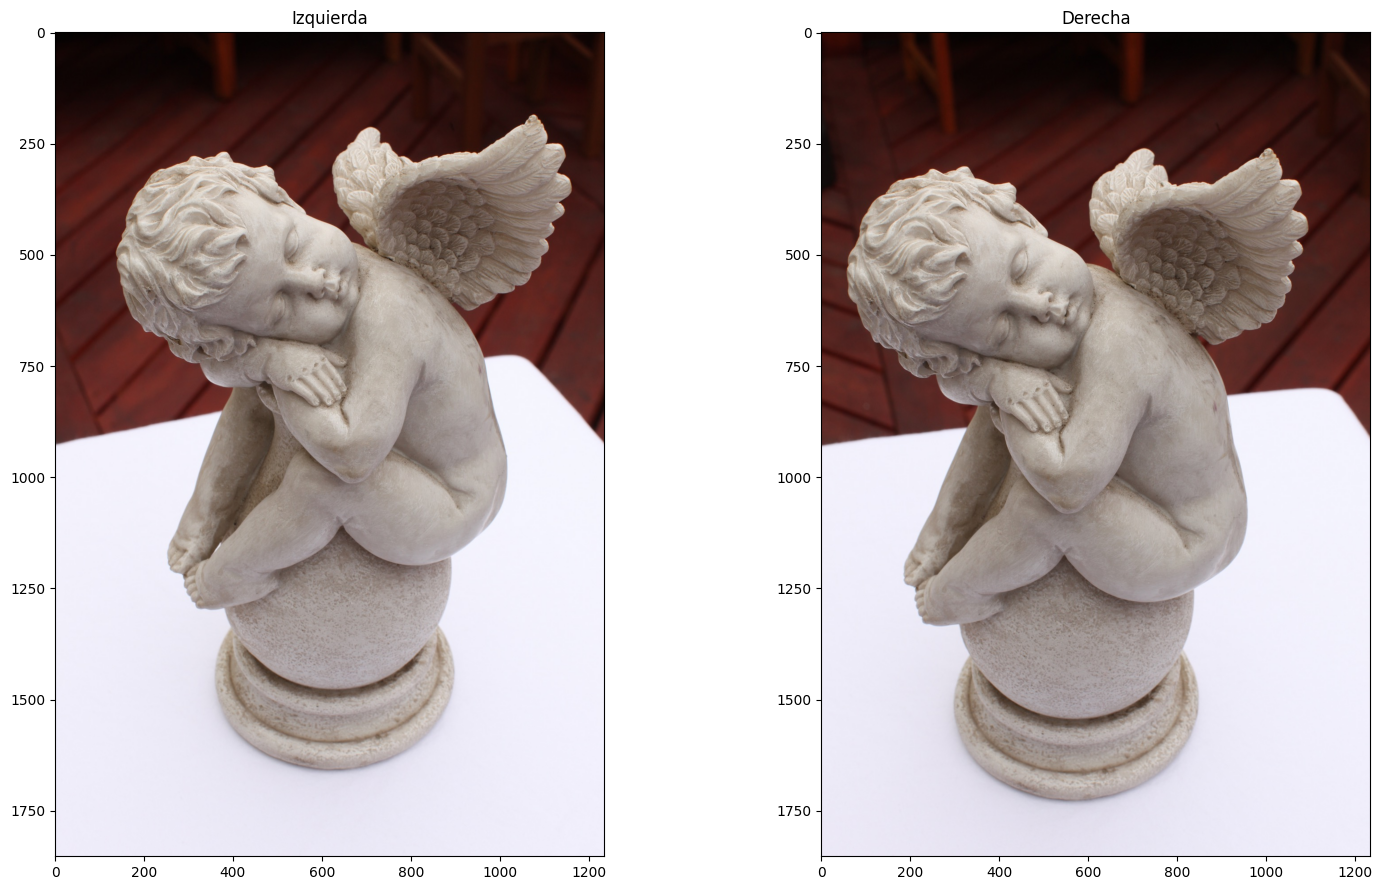

In [ ]:
left = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
right = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,9))

plt.subplot(1,2,1)
plt.imshow(left)
plt.title("Izquierda")
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(right)
plt.title("Derecha")
plt.axis('on')

plt.tight_layout()
plt.savefig('../dataset/plots/'+img1_path+'_and_'+img2_path+'.png')
plt.show()

In [ ]:
if os.path.exists("../dataset/keypoints/pts1-"+img1_path+".npy") and os.path.exists("../dataset/keypoints/pts2-"+img2_path+".npy"):
    # Cargo los puntos homologos calculados con SIFT que han sido calculados anteriormente
    pts1 = np.load("../dataset/keypoints/pts1-"+img1_path+".npy")
    pts2 = np.load("../dataset/keypoints/pts2-"+img2_path+".npy")
else:
    # Usamos el algoritmo SIFT para obtener los puntos homólogos
    pts1, pts2 = find_correspondence_points(img1, img2, ratio_param=0.8)
    
    #Guardar los puntos
    np.save("../dataset/keypoints/pts1-"+img1_path+".npy", pts1)
    np.save("../dataset/keypoints/pts2-"+img2_path+".npy", pts2)

In [20]:
print(pts1.shape)
print(pts2.shape)

(2, 523)
(2, 523)


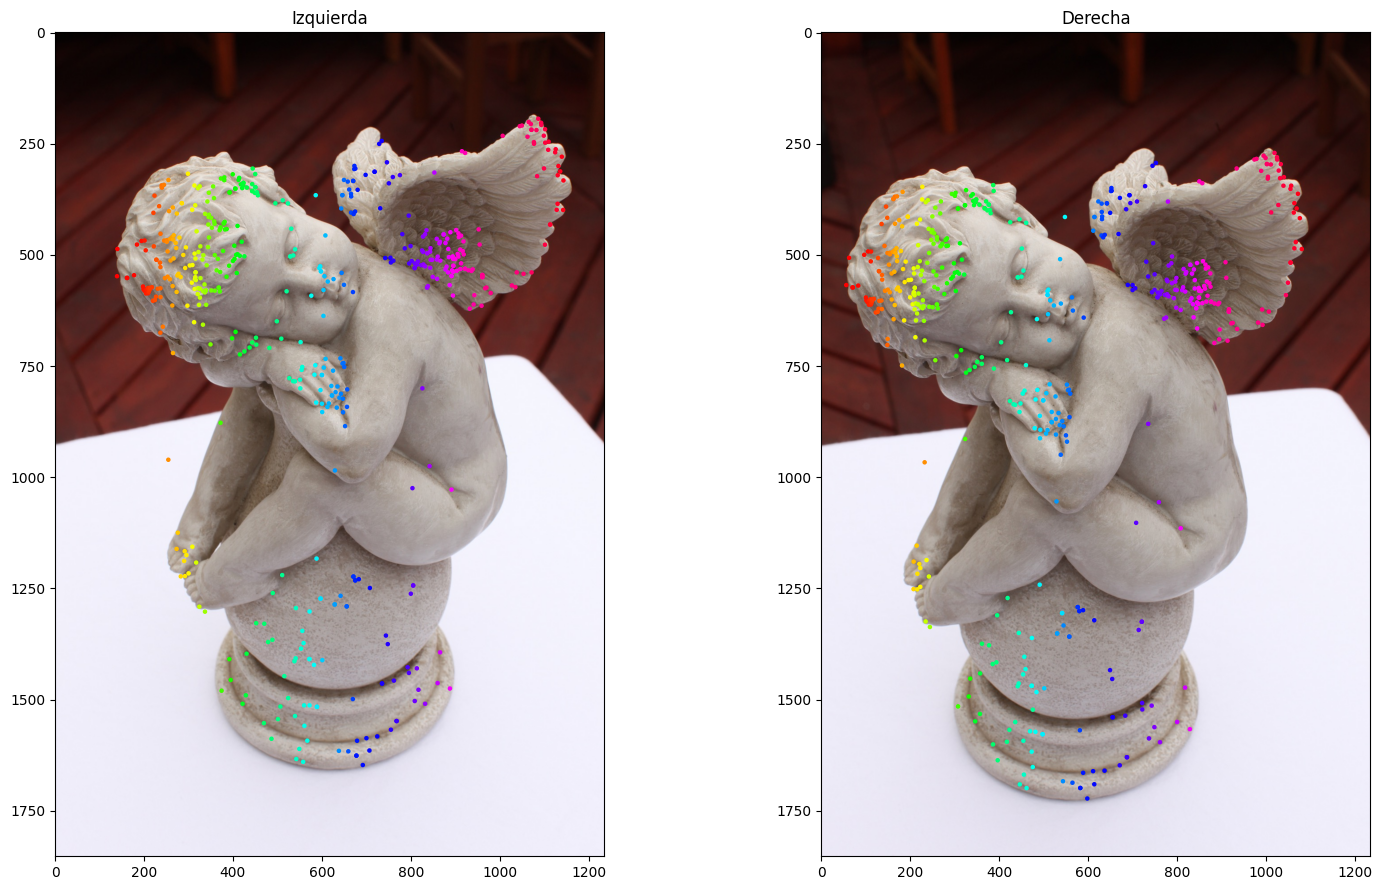

In [ ]:
# Rango de puntos
start = 0
end = pts1.shape[1]

pts1_sub = pts1[:, start:end]
pts2_sub = pts2[:, start:end]

N = pts1_sub.shape[1]
#colors = np.random.rand(N,3) # Colores Aleatorios
colors = plt.cm.hsv(np.linspace(0, 1, N)) # Coores más vivos

plt.figure(figsize=(16,9))

plt.subplot(1,2,1)
plt.imshow(left)
plt.scatter(pts1_sub[0], pts1_sub[1], s=5, c=colors)
plt.title("Izquierda")
plt.axis('on')

plt.subplot(1,2,2)
plt.imshow(right)
plt.scatter(pts2_sub[0], pts2_sub[1], s=5, c=colors)
plt.title("Derecha")
plt.axis('on')

plt.tight_layout()
plt.savefig('../dataset/plots/keypoints_'+img1_path+'_and_'+img2_path+'.png')
plt.show()

In [34]:
F, idx = ransac_fundamental_matrix(pts1, pts2, num_iters=2000,threshold=1.9)

epipole1 = compute_epipole(F)
epipole2 = compute_epipole(F.T)

In [35]:
A = skew(epipole2) @ F
A

array([[-7.24819619e-02,  7.29837412e-01,  4.26965019e+01],
       [ 5.60612118e-01, -5.64504627e+00, -3.30217862e+02],
       [ 2.69266633e-03,  5.49490161e-04, -6.02878652e+00]])

In [36]:
U, D, V = np.linalg.svd(F)
W = np.array([[0,-1,0],[1,0,0],[0,0,1]])
Z = np.array([[0,-1,0],[1,0,0],[0,0,0]])

D = np.diag([D[0],D[1], (D[0]+D[1])/2])

S = U @ Z @ U.T 

M = U @ W.T @ D @ V

print(F)
print(S @ M)

[[-2.48235011e-08 -1.63966434e-06  3.18097079e-04]
 [ 1.44322045e-06  8.31825203e-08 -3.19738005e-03]
 [-3.01146162e-04  3.03237014e-03  1.77384558e-01]]
[[-2.48235011e-08 -1.63966434e-06  3.18097079e-04]
 [ 1.44322045e-06  8.31825203e-08 -3.19738005e-03]
 [-3.01146162e-04  3.03237014e-03  1.77384558e-01]]


In [37]:
epipole2

array([1.86159485e+03, 2.40682193e+02, 1.00000000e+00])

In [38]:
P1 = np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = np.hstack((M, epipole2.reshape(3, 1)))
print(P1)
print(P2)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
[[ 8.77440992e-02  6.77900566e-03  2.27859109e-02  1.86159485e+03]
 [ 1.16479268e-02 -2.18116398e-03 -1.75915021e-01  2.40682193e+02]
 [ 4.85890649e-05  3.72537918e-06 -3.21175255e-03  1.00000000e+00]]


In [39]:
pts1_in = pts1[:,idx]
pts2_in = pts2[:,idx]

M = linear_triangulation(pts1_in, pts2_in, P1, P2)

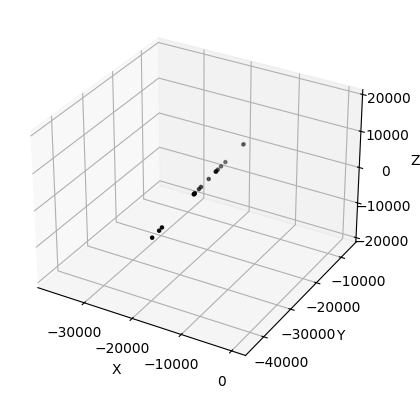

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(M[0, :], M[1, :], M[2, :], c='k', s=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

x_limits = ax.get_xlim3d()
y_limits = ax.get_ylim3d()
z_limits = ax.get_zlim3d()

x_range = abs(x_limits[1] - x_limits[0])
y_range = abs(y_limits[1] - y_limits[0])
z_range = abs(z_limits[1] - z_limits[0])

max_range = max(x_range, y_range, z_range)

mid_x = sum(x_limits) / 2
mid_y = sum(y_limits) / 2
mid_z = sum(z_limits) / 2

ax.set_xlim3d([mid_x - max_range/2, mid_x + max_range/2])
ax.set_ylim3d([mid_y - max_range/2, mid_y + max_range/2])
ax.set_zlim3d([mid_z - max_range/2, mid_z + max_range/2])

plt.show()